   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB
None
               age          bmi     children       charges
count  2772.000000  2772.000000

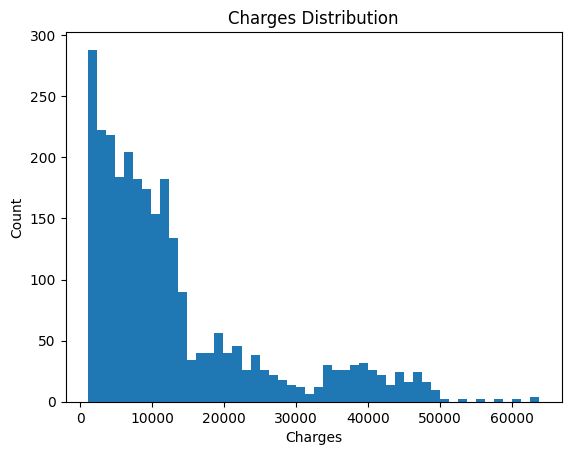

In [2]:
# Part 1: EDA
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("medical_insurance.csv")
print(df.head())
print(df.info())
print(df.describe())

# Distribution of charges
plt.hist(df['charges'], bins=50)
plt.title('Charges Distribution')
plt.xlabel('Charges')
plt.ylabel('Count')
plt.show()


In [7]:
# Part 2: Preprocessing
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

df = pd.read_csv("medical_insurance.csv")

# One-hot encode categorical
enc = OneHotEncoder(sparse_output=False, drop='first')
cat_feats = enc.fit_transform(df[['sex','smoker','region']])
cat_names = enc.get_feature_names_out(['sex','smoker','region'])

num_df = df[['age','bmi','children']]
import numpy as np
X = np.concatenate([num_df.values, cat_feats], axis=1)
y = df['charges'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for deep models
X_train_seq = X_train.reshape((X_train.shape[0], 1, X_train.shape[1]))
X_test_seq = X_test.reshape((X_test.shape[0], 1, X_test.shape[1]))


In [8]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, GRU, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# reshape for deep learning models (timesteps=1, features=n_features)
X_train_cnn = np.expand_dims(X_train, axis=1)
X_test_cnn = np.expand_dims(X_test, axis=1)

# ---------------- CNN model ----------------
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[1])),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_cnn, y_train, epochs=20, batch_size=32, verbose=1)

# ---------------- GRU model ----------------
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_cnn, y_train, epochs=20, batch_size=32, verbose=1)

# ---------------- Ensemble (average predictions) ----------------
y_pred_cnn = cnn_model.predict(X_test_cnn)
y_pred_gru = gru_model.predict(X_test_cnn)

y_pred_ensemble = (y_pred_cnn + y_pred_gru) / 2

# ---------------- Evaluation ----------------
mse = mean_squared_error(y_test, y_pred_ensemble)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ensemble)
r2 = r2_score(y_test, y_pred_ensemble)

print(f"Ensemble CNN+GRU Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 322502016.0000
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 316925952.0000
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 332010752.0000
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 303203520.0000
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 295583360.0000
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 283147424.0000
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 241574784.0000
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 229661856.0000
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 190563600.0000
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 154148880.0000
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 115721832.0000
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 85444464.0000
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 71485664.0000
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 344951840.0000
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 312197696.0000
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 321753536.0000
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 347008512.0000
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 321849824.0000
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 290381408.0000
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 288537536.0000
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 270841248.0000
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 247970816.0000
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 239514768.0000
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 233655392.0000
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 223292192.0000
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 219850176.0000
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

In [9]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# reshape input for CNN/LSTM (samples, timesteps, features)
X_train_seq = np.expand_dims(X_train, axis=1)
X_test_seq = np.expand_dims(X_test, axis=1)

# ---------------- CNN model ----------------
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[1])),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

# ---------------- LSTM model ----------------
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

# ---------------- Ensemble (average predictions) ----------------
y_pred_cnn = cnn_model.predict(X_test_seq)
y_pred_lstm = lstm_model.predict(X_test_seq)

y_pred_ensemble = (y_pred_cnn + y_pred_lstm) / 2

# ---------------- Evaluation ----------------
mse = mean_squared_error(y_test, y_pred_ensemble)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ensemble)
r2 = r2_score(y_test, y_pred_ensemble)

print(f"Ensemble CNN+LSTM Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 332135200.0000
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 337722048.0000
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 334997664.0000
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 324936832.0000
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 273754816.0000
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 275672864.0000
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 248403104.0000
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 224851664.0000
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 189174368.0000
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 151144832.0000
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 122563440.0000
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 90371584.0000
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 73522600.0000
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 339822592.0000
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 315337376.0000
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 329580448.0000
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 327223936.0000
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 316160576.0000
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 307601120.0000
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 298176096.0000
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 274672256.0000
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 308315040.0000
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 267895424.0000
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 278632352.0000
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 261358400.0000
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 257700112.0000
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, GRU, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# reshape input for GRU/LSTM (samples, timesteps, features)
X_train_seq = np.expand_dims(X_train, axis=1)
X_test_seq = np.expand_dims(X_test, axis=1)

# ---------------- GRU model ----------------
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

# ---------------- LSTM model ----------------
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train, epochs=20, batch_size=32, verbose=1)

# ---------------- Ensemble (average predictions) ----------------
y_pred_gru = gru_model.predict(X_test_seq)
y_pred_lstm = lstm_model.predict(X_test_seq)

y_pred_ensemble = (y_pred_gru + y_pred_lstm) / 2

# ---------------- Evaluation ----------------
mse = mean_squared_error(y_test, y_pred_ensemble)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ensemble)
r2 = r2_score(y_test, y_pred_ensemble)

print(f"Ensemble GRU+LSTM Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 312574144.0000
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 314337120.0000
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 309265376.0000
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 318544512.0000
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 311616768.0000
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 309385824.0000
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 293771040.0000
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 280972928.0000
Epoch 9/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 256572976.0000
Epoch 10/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 234986304.0000
Epoch 11/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 245885136.0000
Epoch 12/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 201649904.0000
Epoch 13/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 200188992.0000
Epoch 14/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss:

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, Flatten, GRU, LSTM, Dropout
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# reshape input for CNN/GRU/LSTM (samples, timesteps, features)
X_train_seq = np.expand_dims(X_train, axis=1)
X_test_seq = np.expand_dims(X_test, axis=1)

# ---------------- CNN model ----------------
cnn_model = Sequential([
    Conv1D(filters=64, kernel_size=1, activation='relu', input_shape=(1, X_train.shape[1])),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1)
])
cnn_model.compile(optimizer='adam', loss='mse')
cnn_model.fit(X_train_seq, y_train, epochs=120, batch_size=32, verbose=1)

# ---------------- GRU model ----------------
gru_model = Sequential([
    GRU(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mse')
gru_model.fit(X_train_seq, y_train, epochs=120, batch_size=32, verbose=1)

# ---------------- LSTM model ----------------
lstm_model = Sequential([
    LSTM(64, activation='tanh', input_shape=(1, X_train.shape[1])),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_train_seq, y_train, epochs=120, batch_size=32, verbose=1)

# ---------------- Ensemble (average predictions) ----------------
y_pred_cnn = cnn_model.predict(X_test_seq)
y_pred_gru = gru_model.predict(X_test_seq)
y_pred_lstm = lstm_model.predict(X_test_seq)

y_pred_ensemble = (y_pred_cnn + y_pred_gru + y_pred_lstm) / 3

# ---------------- Evaluation ----------------
mse = mean_squared_error(y_test, y_pred_ensemble)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_ensemble)
r2 = r2_score(y_test, y_pred_ensemble)

print(f"Ensemble CNN+GRU+LSTM Performance:")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MSE: {mse:.4f}")
print(f"R² Score: {r2:.4f}")


Epoch 1/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 354955456.0000
Epoch 2/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 353808000.0000
Epoch 3/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 309106016.0000
Epoch 4/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 337289632.0000
Epoch 5/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 309939648.0000
Epoch 6/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 301929568.0000
Epoch 7/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 267181888.0000
Epoch 8/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 243308352.0000
Epoch 9/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 189700640.0000
Epoch 10/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 165442256.0000
Epoch 11/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 132397680.0000
Epoch 12/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 92504560.0000
Epoch 13/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 73108600.0000
Epoch 14/120
70/70 ━━━━━━━━━━━━━━━━━

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 333512832.0000
Epoch 2/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 336588416.0000
Epoch 3/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 322204896.0000
Epoch 4/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 320225728.0000
Epoch 5/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 299475968.0000
Epoch 6/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 292796384.0000
Epoch 7/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 307569408.0000
Epoch 8/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 271156928.0000
Epoch 9/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 252970784.0000
Epoch 10/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 273390656.0000
Epoch 11/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 224101792.0000
Epoch 12/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 201715312.0000
Epoch 13/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 194294800.0000
Epoch 14/120
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms